In [ ]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
manifold_type  = 'S2'
manifold = Hypersphere(2); manifold_type = 'S2'


In [13]:
def synthetic_experiment__fixedSampleSizeIncreasingSigma(n_samples, Ms, num_modes, tau2s, sigma2s, rhos, num_oracle_samples, oracle_bandwidth, NMC):
    records = [] 
    for num_modes, tau2, M in zip(num_modes, tau2s, Ms):

        G_params = {'tau2': tau2 / num_modes, 'num_modes': num_modes} 

        for ixsigma2, sigma2 in enumerate(sigma2s):

            loss_Ns, loss_oracleTs, loss_oracleBs = [], [], []

            delta_by_rho_losses = np.zeros((NMC, len(rhos)))

            for imc in tqdm(range(NMC), desc=f'modes={num_modes}, σ²={sigma2}', leave=False):

                Theta = multimodal_sampler(n_samples, manifold_type, G_params)
                X = manifold.random_riemannian_normal(Theta, 1 / sigma2, n_samples)

                loss_Ns.append((manifold.metric.squared_dist(X, Theta)).mean())

                _, hat_f, hat_grad_f = density_estimate(manifold_type, X, M, X)
                for ixrho, rho in enumerate(rhos):
                    delta_by_rho_losses[imc, ixrho] = np.mean(
                        manifold.metric.squared_dist(
                            denoiser('S1', X, M, rho, sigma2, X, densityIn=(hat_f, hat_grad_f)),
                            Theta
                        )
                    )

                oracle_delta_T = oracle_denoiser(manifold_type, num_oracle_samples, sigma2,oracle_bandwidth, X,lambda n: multimodal_sampler(n, manifold_type, G_params))
                loss_oracleTs.append((manifold.metric.squared_dist(oracle_delta_T, Theta)).mean())

                oracle_delta_B = oracle_bayes(manifold_type, num_oracle_samples, sigma2,oracle_bandwidth, X,lambda n: multimodal_sampler(n, manifold_type, G_params))
                loss_oracleBs.append((manifold.metric.squared_dist(oracle_delta_B, Theta)).mean())

            # select rho and keep only its losses
            rho_star_idx = np.argmin(delta_by_rho_losses.mean(axis=0))
            loss_Ts = delta_by_rho_losses[:, rho_star_idx]

            records.append(pd.DataFrame({
                "num_modes": [num_modes] * NMC,
                "sigma2": [sigma2] * NMC,
                "mc": np.arange(NMC),
                "Empirical Denoised": loss_Ts,
                "Naïve": loss_Ns,
                "Oracle Denoised": loss_oracleTs,
                "Oracle Bayes": loss_oracleBs,
                "rho" : rhos[rho_star_idx]
            }))


    df = pd.concat(records, ignore_index=True)
    df_long = df.melt(
            id_vars=["num_modes", "sigma2", "mc"],
            value_vars=["Naïve","Empirical Denoised", "Oracle Denoised", "Oracle Bayes"],
            var_name="Loss Type",
            value_name="Loss"
            )
    return df_long

# Fixed $n$, increasing $\sigma^2$

In [11]:
n_samples = 1000

Ms = [2,3,4,5]

num_modes =  [1, 2, 3, 4]
tau2s = [0.1,0.08,0.06,0.04]
sigma2s = np.linspace(0.005, 0.25, 5)
rhos = np.linspace(0.5, 0.005, len(sigma2s))

num_oracle_samples = 10000
oracle_bandwidth = 0.25

NMC = 3

modes=1, σ²=0.18875:  33%|███▎      | 1/3 [00:04<00:08,  4.04s/it]

No points found within bandwidth 0.2500. Increasing bandwidth.


modes=1, σ²=0.18875:  67%|██████▋   | 2/3 [00:07<00:03,  3.60s/it]

No points found within bandwidth 0.2500. Increasing bandwidth.


No points found within bandwidth 0.2500. Increasing bandwidth.


...

modes=2, σ²=0.005:  67%|██████▋   | 2/3 [00:09<00:04,  4.77s/it]

No points found within bandwidth 0.2500. Increasing bandwidth.


modes=3, σ²=0.06625:  67%|██████▋   | 2/3 [00:08<00:04,  4.25s/it]

No points found within bandwidth 0.2500. Increasing bandwidth.


No points found within bandwidth 0.2500. Increasing bandwidth.


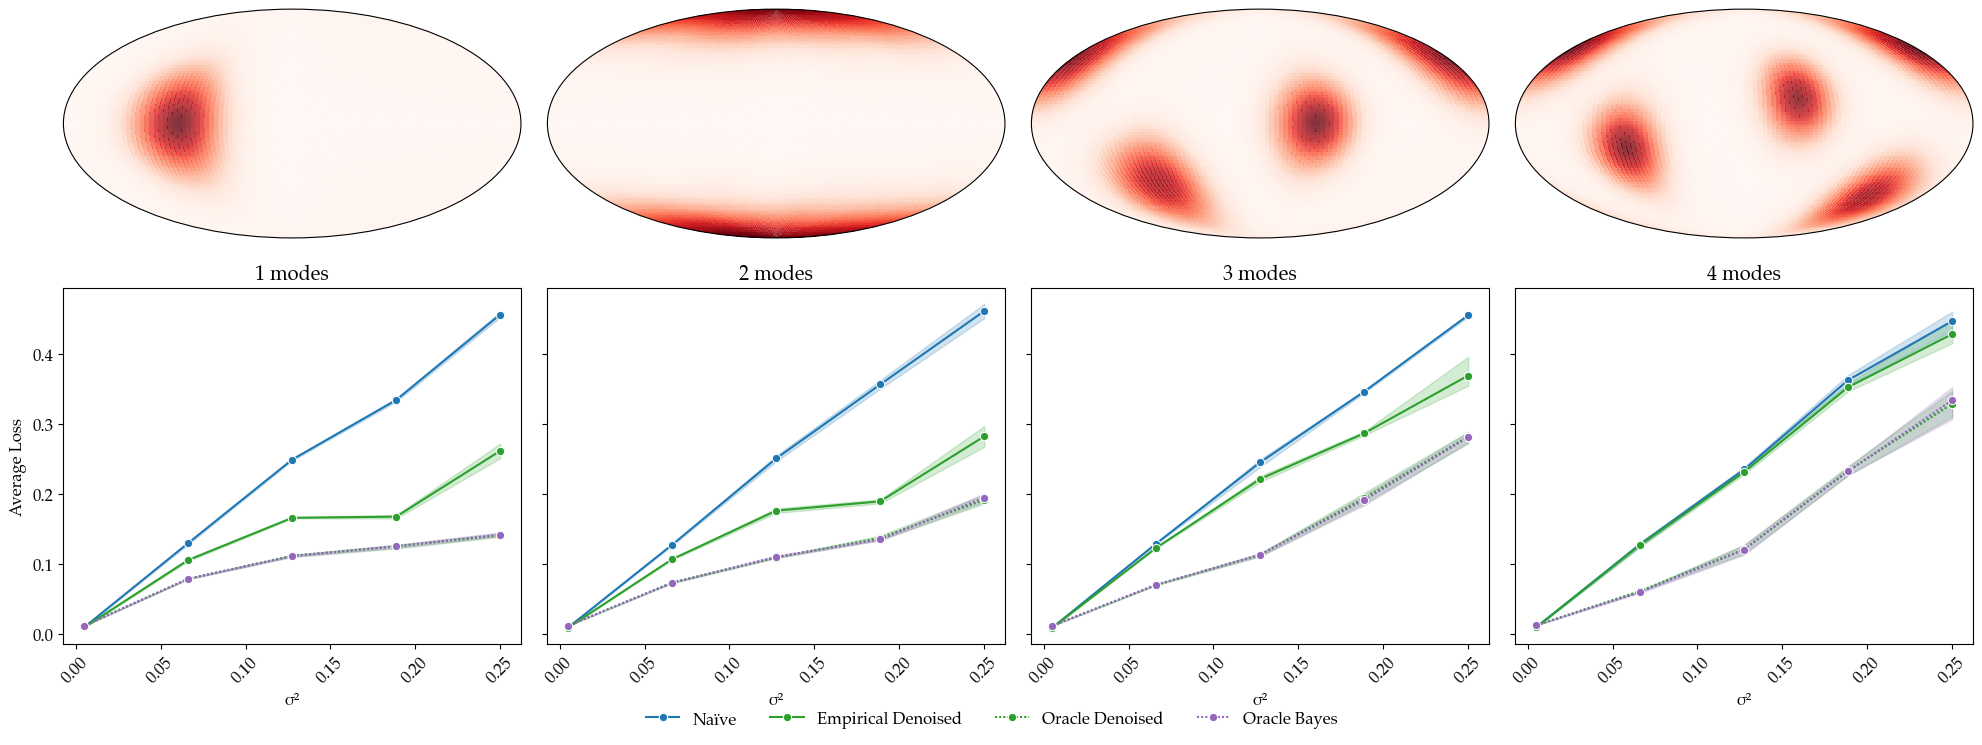

In [ ]:
if True:
    fig, axs = plt.subplots(2, len(num_modes), figsize=(20, 8))

    for idx, (tau2, num_modes, M ) in enumerate(zip(tau2s, num_modes, Ms)):
        axs[0, idx].remove()
        ax0 = fig.add_subplot(2, len(num_modes), 1 + idx, projection="mollweide")
        axs[0, idx] = ax0
        axs[0, idx].set_xticks([])
        axs[0, idx].set_yticks([])
        axs[0, idx].grid(True, alpha=0.3)
        Theta = multimodal_sampler(  n_samples, {'tau2': tau2, 'num_modes': num_modes})
        
        grid_resolution = 100
        grid, grid_theta, grid_phi = S2grid(grid_resolution)
        _, hat_f, grad_hat_f, = kernel_density_estimate('S2', Theta, 20, grid)
        im = axs[0, idx].pcolormesh( grid_phi - np.pi, np.pi/2 - grid_theta, hat_f.reshape(grid_resolution,grid_resolution), alpha=0.8, shading='auto', cmap='Reds')

        sns.lineplot(
            data=df_long[df_long['num_modes'] == num_modes],
            x="sigma2",
            y="Loss",
            hue="Loss Type",
            hue_order=["Naïve","Empirical Denoised", "Oracle Denoised", "Oracle Bayes"],
            palette={
                "Naïve": "C0",
                "Empirical Denoised": "C2",
                "Oracle Denoised": "C2",
                "Oracle Bayes": "C4",
            },
            style="Loss Type",  # map linestyle to hue categories
            dashes={
                "Naïve": "",
                "Empirical Denoised": "",
                "Oracle Denoised": (1, 1),
                "Oracle Bayes": (1, 1),
            },
            estimator="mean",
            errorbar=("ci", 68),  # 1-sigma style band; use 95 if you prefer
            marker="o",
            ax=axs[1, idx],
        )
        # single shared legend (one row) placed below all subplots
        handles, labels = axs[1, idx].get_legend_handles_labels()
        axs[1, idx].get_legend().remove()
        if idx == len(num_modes) - 1:
            fig.legend(handles,labels,loc="lower center",ncol=len(labels),frameon=False,bbox_to_anchor=(0.5, -.02))
        axs[1, idx].set_title(f"{num_modes} modes")
        axs[1, idx].set_xlabel("σ²")
        axs[1, idx].set_ylabel("Average Loss")
        axs[1, idx].tick_params(axis='x', rotation=45)
        
        # Share y-axes across rows and hide repeated y tick labels within each row
        base = axs[1, 0]
        for c in range(1, axs.shape[1]):
            axs[1, c].sharey(base)
            axs[1, c].set_ylabel("")
            axs[1, c].tick_params(labelleft=False)
            # axs[1, c].set_yscale("log"); 
            # axs[1, c].set_xscale("log")

    plt.tight_layout()
    plt.show()

# Fixed $\sigma^2$, increasing $n$

In [ ]:
sigma2 = 0.1

n_samples = [1000,2500, 5000]
# n_samples = [1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]


num_modes =  [1, 2, 3, 4]
Ms = [3 for _ in num_modes]
rhos = [1e-1 for _ in num_modes]

tau2s = [0.05 for _ in num_modes]

NMC = 10

num_oracle_samples = 10000
oracle_bandwidth = 0.001

test_size = 1000

records = []  # Collect all data across num_modes
for num_modes, tau2  in zip(num_modes, tau2s):
    G_params = {'tau2': tau2 , 'num_modes': num_modes} 

    for n_samples, M, rho in zip(n_samples, Ms, rhos):
        loss_Ts, loss_Ns, loss_oracleTs, loss_oracleBs = [], [], [], []

        for imc in tqdm(range(NMC), desc=f'modes={num_modes}, n={n_samples}', leave = False ):

            test_Theta = multimodal_sampler(test_size, manifold_type, G_params)
            test_X = manifold.random_riemannian_normal(test_Theta, 1./sigma2, test_size)

            Theta = multimodal_sampler(n_samples, manifold_type, G_params)
            X = manifold.random_riemannian_normal(Theta, 1./sigma2, n_samples)
            
            delta = denoiser('S2', X, M, rho, sigma2, test_X) 
            
            oracle_delta_T = oracle_denoiser(manifold_type, num_oracle_samples, sigma2, oracle_bandwidth, test_X, lambda n: multimodal_sampler(n, manifold_type, G_params) )

            loss_Ts.append( sq_loss(manifold, delta, test_Theta))
            loss_Ns.append( sq_loss(manifold, test_X, test_Theta) )
            loss_oracleTs.append( sq_loss(manifold, oracle_delta_T, test_Theta) )

        records.append(pd.DataFrame({
            "num_modes": [num_modes] * NMC,
            "num_samples": [n_samples] * NMC,
            "mc": np.arange(NMC),
            "Empirical Denoised": loss_Ts,
            "Naïve": loss_Ns,
            "Oracle Denoised": loss_oracleTs,
        }))

df = pd.concat(records, ignore_index=True)
df_long = df.melt(
        id_vars=["num_modes", "num_samples", "mc"],
        value_vars=["Naïve","Empirical Denoised", "Oracle Denoised"],
        var_name="Loss Type",
        value_name="Loss"
        )
df_box = (df_long.pivot(index=["num_modes", "num_samples", "mc"],columns="Loss Type",values="Loss").reset_index())


In [6]:
df_long.groupby(
    ['num_modes','num_samples']
).aggregate(
    mean_loss = ("Loss", "mean"),
    std_loss = ("Loss", "std")
)


mean_loss  std_loss
num_modes num_samples                     
1         1000          0.143367  0.037139
          2500          0.141924  0.037261
          5000          0.141899  0.036686
2         1000          0.073866  0.020856
          2500          0.072991  0.020973
          5000          0.073098  0.021385
3         1000          0.159419  0.023668
          2500          0.164409  0.023417
          5000          0.162186  0.022738
4         1000          0.183987  0.012958
          2500          0.182689  0.010723
          5000          0.185750  0.011282

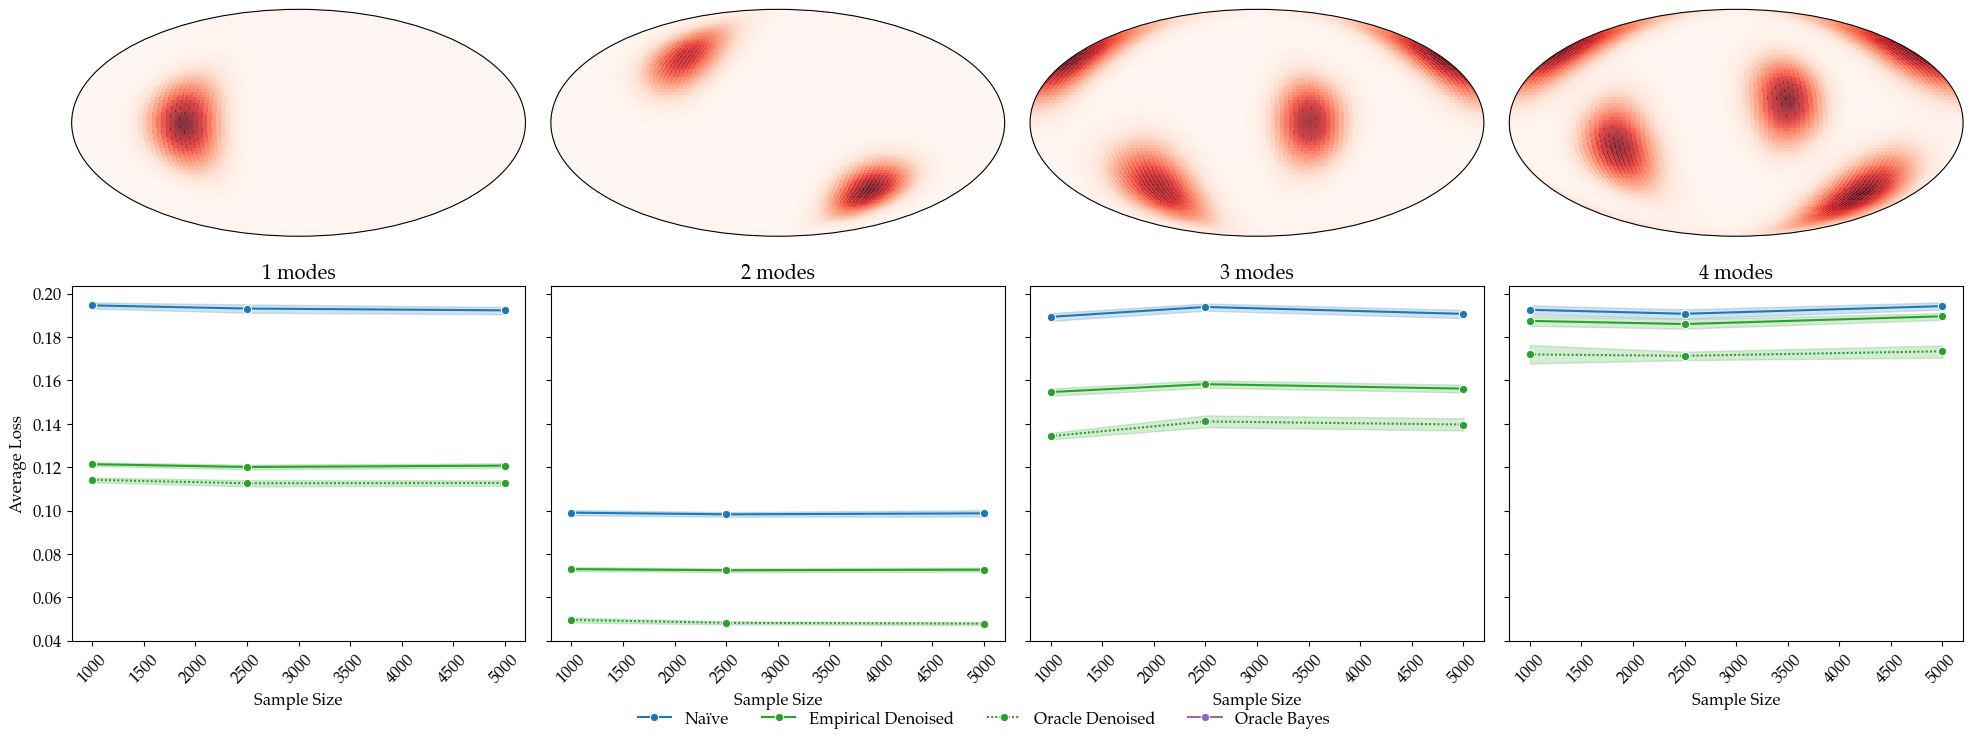

In [ ]:
if True:
    fig, axs = plt.subplots(2, len(num_modes), figsize=(20, 8))

    for idx, (tau2, num_modes,) in enumerate(zip(tau2s, num_modes)):
        axs[0, idx].remove()
        ax0 = fig.add_subplot(2, len(num_modes), 1 + idx, projection="mollweide")
        axs[0, idx] = ax0
        axs[0, idx].set_xticks([])
        axs[0, idx].set_yticks([])
        axs[0, idx].grid(True, alpha=0.3)
        Theta = multimodal_sampler(  1000, manifold_type, {'tau2': tau2, 'num_modes': num_modes})
        
        grid_resolution = 100
        grid, grid_theta, grid_phi = S2grid(grid_resolution)
        _, hat_f, grad_hat_f, = kernel_density_estimate('S2', Theta, 20, grid)
        im = axs[0, idx].pcolormesh( grid_phi - np.pi, np.pi/2 - grid_theta, hat_f.reshape(grid_resolution,grid_resolution), alpha=0.8, shading='auto', cmap='Reds')

        sns.lineplot(
            data=df_long[df_long['num_modes'] == num_modes],
            x="num_samples",
            y="Loss",
            hue="Loss Type",
            hue_order=["Naïve","Empirical Denoised", "Oracle Denoised", "Oracle Bayes"],
            palette={
                "Naïve": "C0",
                "Empirical Denoised": "C2",
                "Oracle Denoised": "C2",
                "Oracle Bayes": "C4",
            },
            style="Loss Type",  # map linestyle to hue categories
            dashes={
                "Naïve": "",
                "Empirical Denoised": "",
                "Oracle Denoised": (1, 1),
                "Oracle Bayes": (1, 1),
            },
            estimator="mean",
            errorbar=("ci", 68),  # 1-sigma style band; use 95 if you prefer
            marker="o",
            ax=axs[1, idx],
        )
        # single shared legend (one row) placed below all subplots
        handles, labels = axs[1, idx].get_legend_handles_labels()
        axs[1, idx].get_legend().remove()
        if idx == len(num_modes) - 1:
            fig.legend(handles,labels,loc="lower center",ncol=len(labels),frameon=False,bbox_to_anchor=(0.5, -.02))
        axs[1, idx].set_title(f"{num_modes} modes")
        axs[1, idx].set_xlabel("Sample Size")
        axs[1, idx].set_ylabel("Average Loss")
        axs[1, idx].tick_params(axis='x', rotation=45)
        
        # Share y-axes across rows and hide repeated y tick labels within each row
        base = axs[1, 0]
        for c in range(1, axs.shape[1]):
            axs[1, c].sharey(base)
            axs[1, c].set_ylabel("")
            axs[1, c].tick_params(labelleft=False)
            # axs[1, c].set_yscale("log"); axs[1, c].set_xscale("log")

    plt.tight_layout()
    plt.show()

In [ ]:
# n_samples = [250, 500, 750, 1000, 1250, 1500, 1750, 2000]
n_samples = [100, 500, 1000, 2000, 3000]
Ms =  [6 for _ in n_samples]
rho = 1e-2


num_oracle_samples = 10000
num_modes = 2

tau2 = 0.05
sigma2 = 0.1

NMC = 5
oracle_bandwidth = .5

# ----------------------------------------------------------------------------------------------------
records = []
for n_samples, M in zip(n_samples, Ms):
    loss_Ts, loss_oracleTs = [], []

    for imc in tqdm(range(NMC), desc=f"n={n_samples}", leave=False):
        G_params = {'tau2': tau2, 'num_modes': num_modes}
        Theta = multimodal_sampler(n_samples, manifold_type, G_params)
        X = manifold.random_riemannian_normal(Theta, 1.0 / sigma2, n_samples)
    
        delta = denoiser(manifold_type, X, M, rho, sigma2, X)
        oracle_delta_T = oracle_denoiser(manifold_type, num_oracle_samples, sigma2, oracle_bandwidth, X, lambda n: multimodal_sampler(n, manifold_type, G_params) )

        loss_Ts.append(np.mean(manifold.metric.squared_dist(delta,Theta)))
        loss_oracleTs.append(np.mean(manifold.metric.squared_dist(oracle_delta_T,Theta)))
    
    records.append(pd.DataFrame({
        "n_samples": [n_samples] * NMC,
        "mc": np.arange(NMC),
        "Empirical Denoised": loss_Ts,
        "Oracle Denoised": loss_oracleTs,
    }))

df_mc = pd.concat(records, ignore_index=True)
print((df_mc.groupby("n_samples")[["Empirical Denoised", "Oracle Denoised"]]
                 .agg(["mean", "std"])
                 .reset_index()))


n=100:   0%|          | 0/5 [00:00<?, ?it/s]

  n_samples Empirical Denoised           Oracle Denoised          
                          mean       std            mean       std
0       100           0.069288  0.011731        0.031715  0.001511
1       500           0.063401  0.007066        0.030706  0.001617
2      1000           0.061255  0.002053        0.031837  0.000832
3      2000           0.058981  0.001973        0.031383  0.001312
4      3000           0.058043  0.001269        0.030750  0.000593


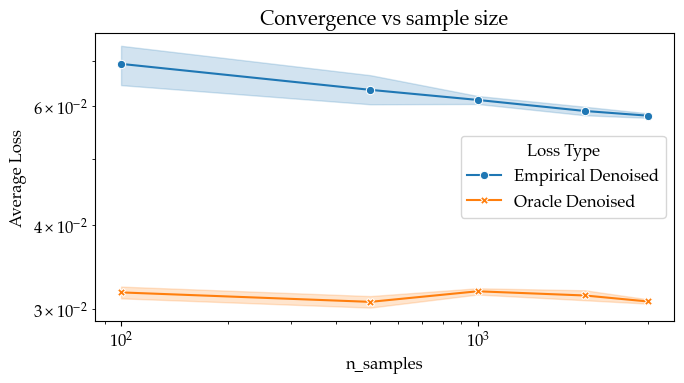

In [5]:
# Plot convergence vs sample size with mean and 68% CI across MC runs
if True:
    df_mc_long = df_mc.melt(
        id_vars=["n_samples", "mc"],
        value_vars=["Empirical Denoised", "Oracle Denoised"],
        var_name="Loss Type",
        value_name="Loss",
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.lineplot(
        data=df_mc_long,
        x="n_samples",
        y="Loss",
        hue="Loss Type",
        style="Loss Type",
        markers=True,
        dashes=False,
        estimator="mean",
        errorbar=("ci", 68),
        ax=ax
    )
    ax.set_yscale("log"); ax.set_xscale("log")
    ax.set_xlabel("n_samples")
    ax.set_ylabel("Average Loss")
    ax.set_title("Convergence vs sample size")
    plt.tight_layout()
    plt.show()

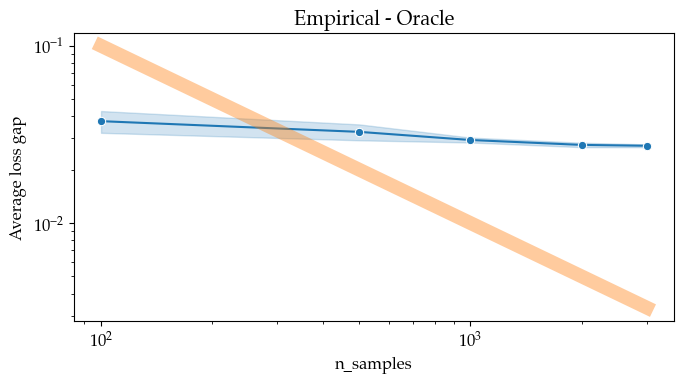

In [ ]:
# Plot convergence vs sample size with mean and 68% CI across MC runs
if True:
    # Per-run difference (Empirical - Oracle)
    df_diff = (
        df_mc.pivot(index=["n_samples", "mc"], columns=None, values=None)
        if False else None
    )

    df_diff = (
        df_mc.set_index(["n_samples", "mc"])[["Empirical Denoised", "Oracle Denoised"]]
        .assign(**{"Difference (Empirical - Oracle)": lambda d: d["Empirical Denoised"] - d["Oracle Denoised"]})
        .reset_index()[["n_samples", "mc", "Difference (Empirical - Oracle)"]]
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.lineplot(
        data=df_diff,
        x="n_samples",
        y="Difference (Empirical - Oracle)",
        estimator="mean",
        errorbar=("ci", 68),
        marker="o",
        ax=ax,
    )
    ax.plot(n_samples, np.array([10/n**(1) for n  in n_samples]), linewidth = 10, alpha=.4 )

    # ax.set_ylim(.5e-2,.3)
    ax.axhline(0, color="k", lw=1, alpha=0.6)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("n_samples")
    ax.set_ylabel("Average loss gap")
    ax.set_title("Empirical - Oracle")
    plt.tight_layout()
    plt.show()

-----

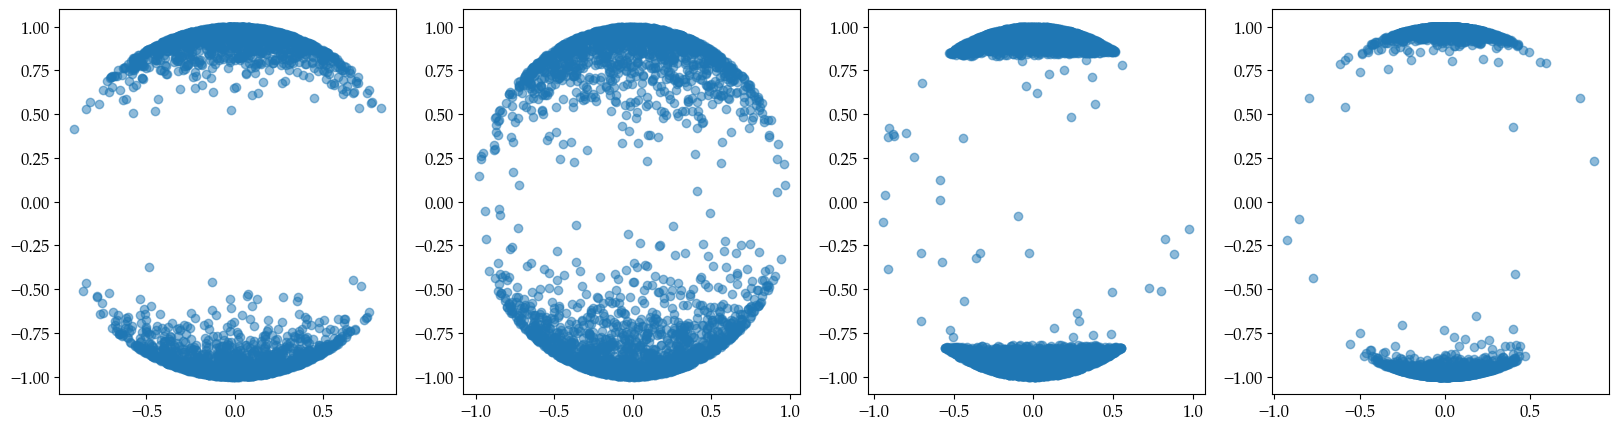

In [8]:
fig, [ax1,ax2,ax3,ax4] = plt.subplots(1,4, figsize=(20,5))
ax1.scatter(Theta[:, 1], Theta[:, 2], alpha=0.5)
ax2.scatter(X[:, 1], X[:, 2], alpha=0.5)
ax3.scatter(delta[:, 1], delta[:, 2], alpha=0.5)
ax4.scatter(oracle_delta_T[:, 1], oracle_delta_T[:, 2], alpha=0.5)